<font size=3;>
<p style="text-align: right;"> Lab Solution --- <b>NOT FOR DISTRIBUTION!</b> </p>
</font>

# Lab E: Simulation

## Setup

In [1]:
# Import some useful functions
from numpy import *
from numpy.random import *
from datascience import *
from statsmodels.formula.api import *

# Define some useful functions
def correlation(array_1, array_2):
    return corrcoef(array_1, array_2).item(1)

# Customize look of graphics
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')
plt.rcParams['figure.dpi'] = 60
%matplotlib inline

# Force display of all values 
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

# Hide some unnecessary warning messages
import warnings
warnings.filterwarnings("ignore")
import numpy
numpy.int = numpy.int_

## Hot Dog Vendor - without investment decision

### Business Situation

A vendor sells hot dogs at sporting events.  For each event, the vendor orders 5,000 hot dogs and pays for them in advance.  Each hot dog costs the vendor \\$3 and, if there is demand for it, can be sold for \\$5.  To assist in estimating demand, the vendor can consult data about demand at the prior 1,000 events.

### Data

Retrieve historical demand data, show the number of observations and the first few observations.

In [2]:
data = Table.read_table('demand_history.csv')
data.num_rows
data

1000

Demand
4435
7087
2739
2586
5250
4570
4546
4811
6552
4859


### Analysis

Calculate and show the mean, minimum, and maximum historical demand.  Visualize historical demand as a 10-bin histogram.

5019.1760000000004

1662

7984

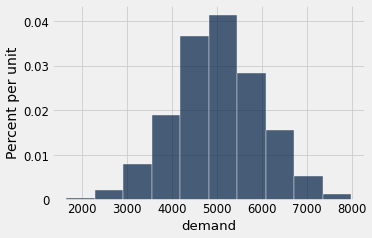

In [3]:
demand_history = data.column('Demand')

mean(demand_history)
min(demand_history)
max(demand_history)

Table().with_column("demand", demand_history).hist()

Set the unit price to \\$5, unit cost to \\$3, and order size to 5,000.
Calculate and show the investment required to make an order.

In [4]:
unit_price = 5 # $/unit
unit_cost  = 3 # $/unit
order  = 5000 # units
invest = order * unit_cost

invest

15000

Assume demand at an event is 5,000 units.  Calculate and show what the profit would be.

In [5]:
demand = 5000 # units
sold = minimum(order, demand) # units
profit = (sold * unit_price) - invest # $

profit

10000

Simulate 5 events.  Assume each event has demand equal to demand at some randomly chosen prior event.  
Visualize the distribution of profit across these 5 events as a 10-bin histogram, range -20,000 to 20,000.

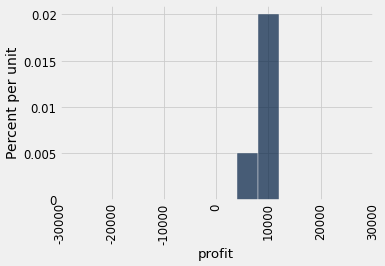

In [6]:
demand = choice(demand_history, 5) # units
sold = minimum(order, demand) # units
profit = (sold * unit_price) - (order * unit_cost) # $

profit_table = Table().with_column('profit', profit)
profit_table.hist(range=make_array(-20000, 20000))

Simulate 1,000,000 events.  Assume each event has demand equal to demand at some randomly chosen prior event.  
Keep track of the would-be profit at each event, stored in an array.  
Visualize the distribution of profits across these 1,000,000 events as a 10-bin histogram, range -20,000 to 20,000.

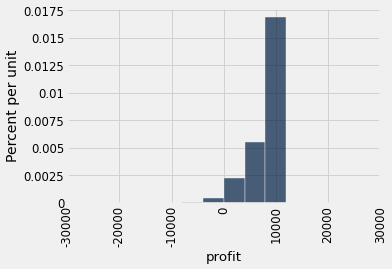

In [7]:
demand = choice(demand_history, 1000000) # units
sold = minimum(order, demand) # units
profit = (sold * unit_price) - (order * unit_cost) # $

profit_table = Table().with_column('profit', profit)
profit_table.hist(range=make_array(-20000, 20000))

Calculate and show the expected profit (i.e., mean profit).

In [8]:
mean(profit)

8118.7203449999997

Calculate and show the best case profit.

In [9]:
max(profit)

10000

Calculate and show the probability of a loss.

In [10]:
profit_table.where('profit', are.below(0)).num_rows / profit_table.num_rows

0.018942

Calculate and show the worst case profit.

In [11]:
min(profit)

-6690

Construct and show a table with columns for
order, invest, expected profit, best case, probability of loss, probability of best case, worst case.

In [12]:
result_5000 = Table().with_columns('order', order,
                                   'invest', invest,
                                   'expected profit', mean(profit),
                                   'best case', max(profit),
                                   'prob loss', profit_table.where('profit', are.below(0)).num_rows/profit_table.num_rows,
                                   'prob best case', profit_table.where('profit', max(profit)).num_rows/profit_table.num_rows,
                                   'worst case', min(profit))

result_5000

order,invest,expected profit,best case,prob loss,prob best case,worst case
5000,15000,8118.72,10000,0.018942,0.510275,-6690


## Hot Dog Vendor - with investment decision

### Business Decision

A vendor sells hot dogs at sporting events.  For each event, the vendor must decide how many hot dogs to order and pay for them in advance.  Each hotdog costs the vendor \\$3 and, if there is demand for it, can be sold for \\$5.  To assist in estimating demand, the vendor can consult data about demand at the prior 1,000 events.

### Data

Use the historical data retrieved in Section 2. 

### Analysis

Set and show the unit price to \\$5 and unit cost to \\$3.

In [13]:
unit_price = 5 # $/unit
unit_cost  = 3 # $/unit
unit_price
unit_cost

5

3

Set the order size to **4,000** and calculate the investment required.

Simulate 1,000,000 events.  Assume each event has demand equal to demand at some randomly chosen prior event.
Keep track of the would-be profit at each event, stored in an array.

Construct and show a table with columns for
order, invest, expected profit, best case, probability of loss, probability of best case, worst case.

Visualize the distribution of profits across these 1,000,000 events as a 10-bin histogram, range -20,000 to 20,000.

order,invest,expected profit,best case,prob loss,prob best case,worst case
4000,12000,7616.25,8000,0.002034,0.854105,-3690


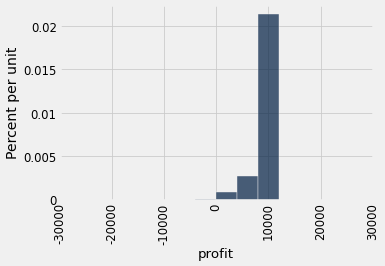

In [14]:
order = 4000 # units
invest = order * unit_cost

demand = choice(demand_history, 1000000) # units
sold = minimum(order, demand) # units
profit = (sold * unit_price) - (order * unit_cost) # $

profit_table = Table().with_column('profit', profit)

result_4000 = Table().with_columns('order', order,
                                   'invest', invest,
                                   'expected profit', mean(profit),
                                   'best case', max(profit),
                                   'prob loss', profit_table.where('profit', are.below(0)).num_rows/profit_table.num_rows,
                                   'prob best case', profit_table.where('profit', max(profit)).num_rows/profit_table.num_rows,
                                   'worst case', min(profit))

result_4000
profit_table.hist(range=make_array(-20000, 20000))

Set the order size to **5,000** and calculate the investment required.

Simulate 1,000,000 events.  Assume each event has demand equal to demand at some randomly chosen prior event.
Keep track of the would-be profit at each event, stored in an array.

Construct and show a table with columns for
order, invest, expected profit, best case, probability of loss, probability of best case, worst case.

Visualize the distribution of profits across these 1,000,000 events as a 10-bin histogram, range -20,000 to 20,000.

order,invest,expected profit,best case,prob loss,prob best case,worst case
5000,15000,8117.13,10000,0.019305,0.510169,-6690


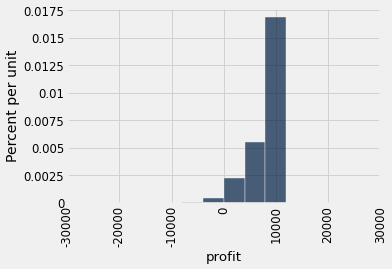

In [15]:
order = 5000 # units
invest = order * unit_cost

demand = choice(demand_history, 1000000) # units
sold = minimum(order, demand) # units
profit = (sold * unit_price) - (order * unit_cost) # $

profit_table = Table().with_column('profit', profit)

result_5000 = Table().with_columns('order', order,
                                   'invest', invest,
                                   'expected profit', mean(profit),
                                   'best case', max(profit),
                                   'prob loss', profit_table.where('profit', are.below(0)).num_rows/profit_table.num_rows,
                                   'prob best case', profit_table.where('profit', max(profit)).num_rows/profit_table.num_rows,
                                   'worst case', min(profit))

result_5000
profit_table.hist(range=make_array(-20000, 20000))

Set the order size to **6,000** and calculate the investment required.

Simulate 1,000,000 events.  Assume each event has demand equal to demand at some randomly chosen prior event.
Keep track of the would-be profit at each event, stored in an array.

Construct and show a table with columns for
order, invest, expected profit, best case, probability of loss, probability of best case, worst case.

Visualize the distribution of profits across these 1,000,000 events as a 10-bin histogram, range -20,000 to 20,000.

order,invest,expected profit,best case,prob loss,prob best case,worst case
6000,18000,6683.58,12000,0.071056,0.160341,-9690


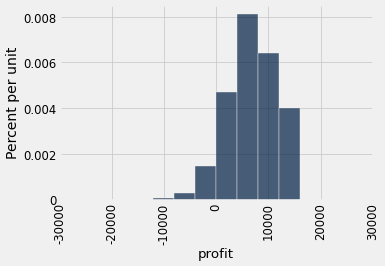

In [16]:
order = 6000 # units
invest = order * unit_cost

demand = choice(demand_history, 1000000) # units
sold = minimum(order, demand) # units
profit = (sold * unit_price) - (order * unit_cost) # $

profit_table = Table().with_column('profit', profit)

result_6000 = Table().with_columns('order', order,
                                   'invest', invest,
                                   'expected profit', mean(profit),
                                   'best case', max(profit),
                                   'prob loss', profit_table.where('profit', are.below(0)).num_rows/profit_table.num_rows,
                                   'prob best case', profit_table.where('profit', max(profit)).num_rows/profit_table.num_rows,
                                   'worst case', min(profit))

result_6000
profit_table.hist(range=make_array(-20000, 20000))

Set the order size to **7,000** and calculate the investment required.

Simulate 1,000,000 events.  Assume each event has demand equal to demand at some randomly chosen prior event.
Keep track of the would-be profit at each event, stored in an array.

Construct and show a table with columns for
order, invest, expected profit, best case, probability of loss, probability of best case, worst case.

Visualize the distribution of profits across these 1,000,000 events as a 10-bin histogram, range -20,000 to 20,000.

order,invest,expected profit,best case,prob loss,prob best case,worst case
7000,21000,4062.75,14000,0.191065,0.02203,-12690


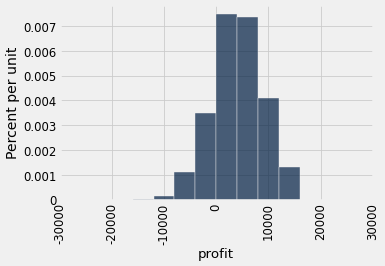

In [17]:
order = 7000 # units
invest = order * unit_cost

demand = choice(demand_history, 1000000) # units
sold = minimum(order, demand) # units
profit = (sold * unit_price) - (order * unit_cost) # $

profit_table = Table().with_column('profit', profit)

result_7000 = Table().with_columns('order', order,
                                   'invest', invest,
                                   'expected profit', mean(profit),
                                   'best case', max(profit),
                                   'prob loss', profit_table.where('profit', are.below(0)).num_rows/profit_table.num_rows,
                                   'prob best case', profit_table.where('profit', max(profit)).num_rows/profit_table.num_rows,
                                   'worst case', min(profit))

result_7000
profit_table.hist(range=make_array(-20000, 20000))

Combine the results into a single table and show the table.

In [18]:
result = result_4000
result = result.with_rows(result_5000.rows)
result = result.with_rows(result_6000.rows)
result = result.with_rows(result_7000.rows)

result

order,invest,expected profit,best case,prob loss,prob best case,worst case
4000,12000,7616.25,8000,0.002034,0.854105,-3690
5000,15000,8117.13,10000,0.019305,0.510169,-6690
6000,18000,6683.58,12000,0.071056,0.160341,-9690
7000,21000,4062.75,14000,0.191065,0.02203,-12690


Visualize the results as a lineplot with expected profit, best case, and worst case vs. order decision.

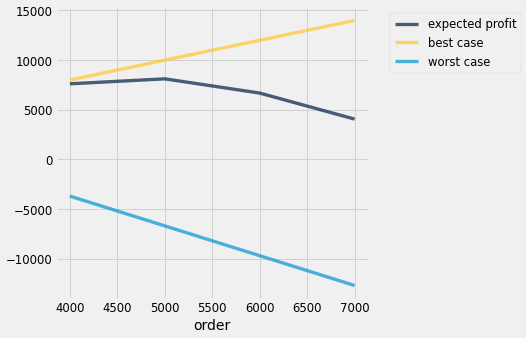

In [19]:
result.select('order','expected profit','best case','worst case').plot('order')

Visualize the results as a lineplot with probability of loss vs. order decision.

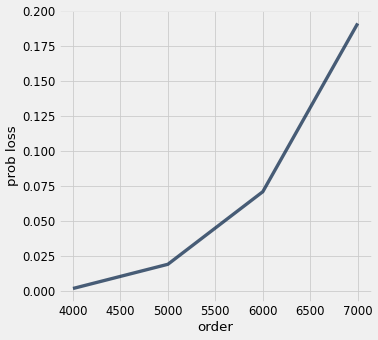

In [20]:
result.select('order','prob loss').plot('order')

Calculate and show the order decision that maximizes expected profit.

In [21]:
best_expected_profit = max(result.column('expected profit'))
result.where('expected profit', best_expected_profit).column('order').item(0)

5000

Calculate and show the order decision that minimizes probability of a loss.

In [22]:
best_prob_loss = min(result.column('prob loss'))
result.where('prob loss', best_prob_loss).column('order').item(0)

4000

Show the order decision that maximizes best case profit.

In [23]:
best_best_case = max(result.column('best case'))
result.where('best case', best_best_case).column('order').item(0)

7000

Show the order decision that maximizes worst case profit.

In [24]:
best_worst_case = max(result.column('worst case'))
result.where('worst case', best_worst_case).column('order').item(0)

4000

Calculate and show the best case profit when decision is to order 4,000.  
Calculate and show the probability of the best case profit when decision is to order 4,000.  
Calculate and show the best case profit when decision is to order 7,000.  
Calculate and show the probability of the best case profit when decision is to order 7,000.

In [25]:
4000, result.where('order', 4000).column('best case').item(0), result.where('order', 4000).column('prob best case').item(0)
7000, result.where('order', 7000).column('best case').item(0), result.where('order', 7000).column('prob best case').item(0)

(4000, 8000, 0.854105)

(7000, 14000, 0.02203)

<p style="text-align:left; font-size:10px;">
Copyright (c) Huntsinger Associates, LLC
<span style="float:right;">
Document revised September 19, 2024
</span>
</p>